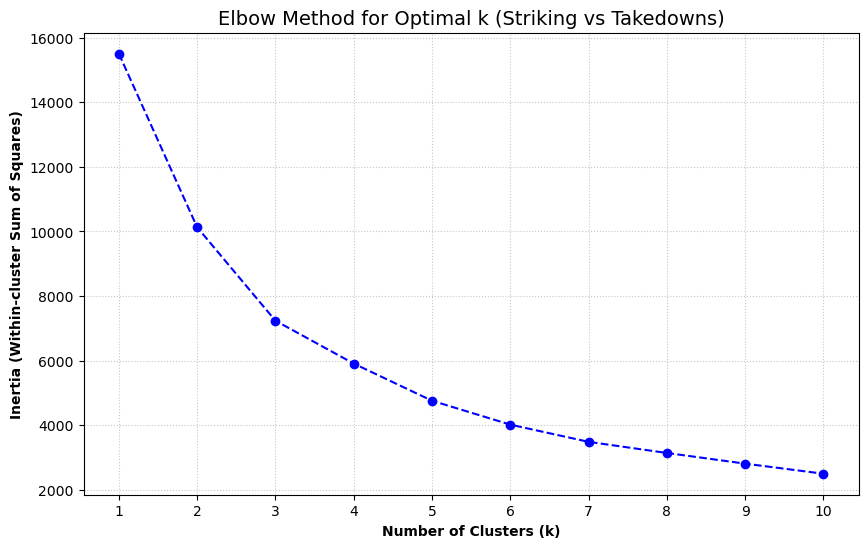

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Discovery Questions; Do weight classes determine fighting style(using clustering), Does having significant reach determine strike accuracy(Using association technqiue)

#Load and clean data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_processed.csv', sep=';')
df.columns = df.columns.str.strip()
#I made a mistake here. I am keeping it as reference for myself
'''fight_data = df[['winner_name;', 'loser_name;', 'event_date;', 'method;', 'round;', 'time;', 'time_format;', 'bout_type;', 'event_name;', 'event_location;', 'winner_stance;', 'loser_stance;', 'winner;', 'delta_KD;', 'delta_sig_str_pct;', 'delta_total_str_pct;', 'delta_TD_pct;', 'delta_sub_att;', 'delta_rev;', 'delta_ctrl;', 'delta_sig_str_head_acc_pct;', 'delta_sig_str_body_acc_pct;', 'delta_sig_str_leg_acc_pct;', 'delta_sig_str_distance_acc_pct;-', 'delta_sig_str_clinch_acc_pct;', 'delta_sig_str_ground_acc_pct;', 'delta_sig_str_head_tar_pct;', 'delta_sig_str_body_tar_pct;', 'delta_sig_str_leg_tar_pct;', 'delta_sig_str_distance_pos_pct;', 'delta_sig_str_clinch_pos_pct;', 'delta_sig_str_ground_pos_pct;', 'delta_height;', 'delta_reach;', 'delta_slpm_cs;', 'delta_str_acc_cs;', 'delta_sapm_cs;', 'delta_str_def_cs;', 'delta_td_avg_cs;', 'delta_td_acc_cs;', 'delta_td_def_cs;', 'delta_sub_avg_cs;'
]]'''


#Filter relevant features and drop NaNs
features = ['delta_sig_str_pct', 'delta_TD_pct']
fight_data = df[features].dropna()

#Preprocess the data
scaler = StandardScaler()
scaled_fights = scaler.fit_transform(fight_data)

#Run KMeans for a range of k values
inertia = []
K_range = range(1, 11)

for k in K_range:
    #Use n_init=10 to suppress warnings and ensure stability
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_fights)
    inertia.append(kmeans.inertia_)

#Plotting the Elbow Method result where the ideal is k = 4
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)', fontweight='bold')
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontweight='bold')
plt.title('Elbow Method for Optimal k (Striking vs Takedowns)', fontsize=14)
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

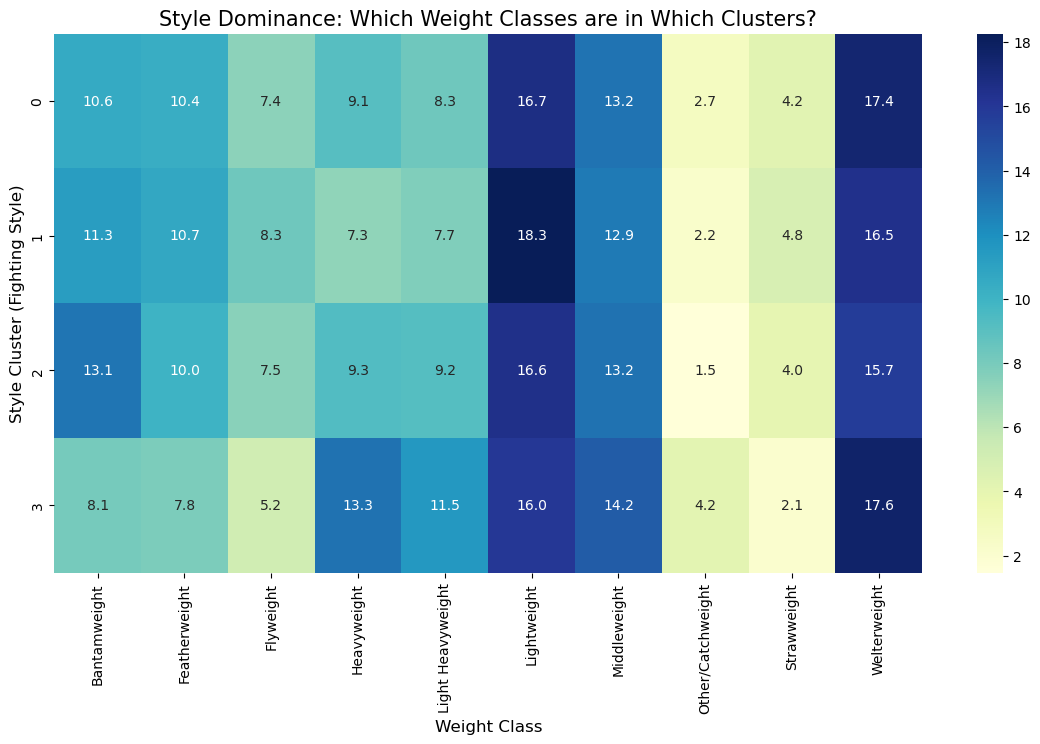

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load Data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_processed.csv', sep=';')
df.columns = df.columns.str.strip()

features = ['delta_sig_str_pct', 'delta_TD_pct']
df_clean = df.dropna(subset=features).copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(scaled_data)

#Simplify Bout Types to Weight Classes
def simplify_bout(bout):
    bout = str(bout).lower()
    if 'light heavyweight' in bout: return 'Light Heavyweight'
    if 'heavyweight' in bout: return 'Heavyweight'
    if 'middleweight' in bout: return 'Middleweight'
    if 'welterweight' in bout: return 'Welterweight'
    if 'lightweight' in bout: return 'Lightweight'
    if 'featherweight' in bout: return 'Featherweight'
    if 'bantamweight' in bout: return 'Bantamweight'
    if 'flyweight' in bout: return 'Flyweight'
    if 'strawweight' in bout: return 'Strawweight'
    return 'Other/Catchweight'

df_clean['weight_class'] = df_clean['bout_type'].apply(simplify_bout)

#Create a Composition Matrix (normalize by 'index' to see % of cluster)
cluster_composition = pd.crosstab(df_clean['cluster'], df_clean['weight_class'], normalize='index') * 100

#Plot Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(cluster_composition, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Style Dominance: Which Weight Classes are in Which Clusters?', fontsize=15)
plt.ylabel('Style Cluster (Fighting Style)', fontsize=12)
plt.xlabel('Weight Class', fontsize=12)
plt.show()

#0 is defensive/balanced styles, 1 is grappling focused, 2 is clinical strikes, 3 is heavy aggression in fights

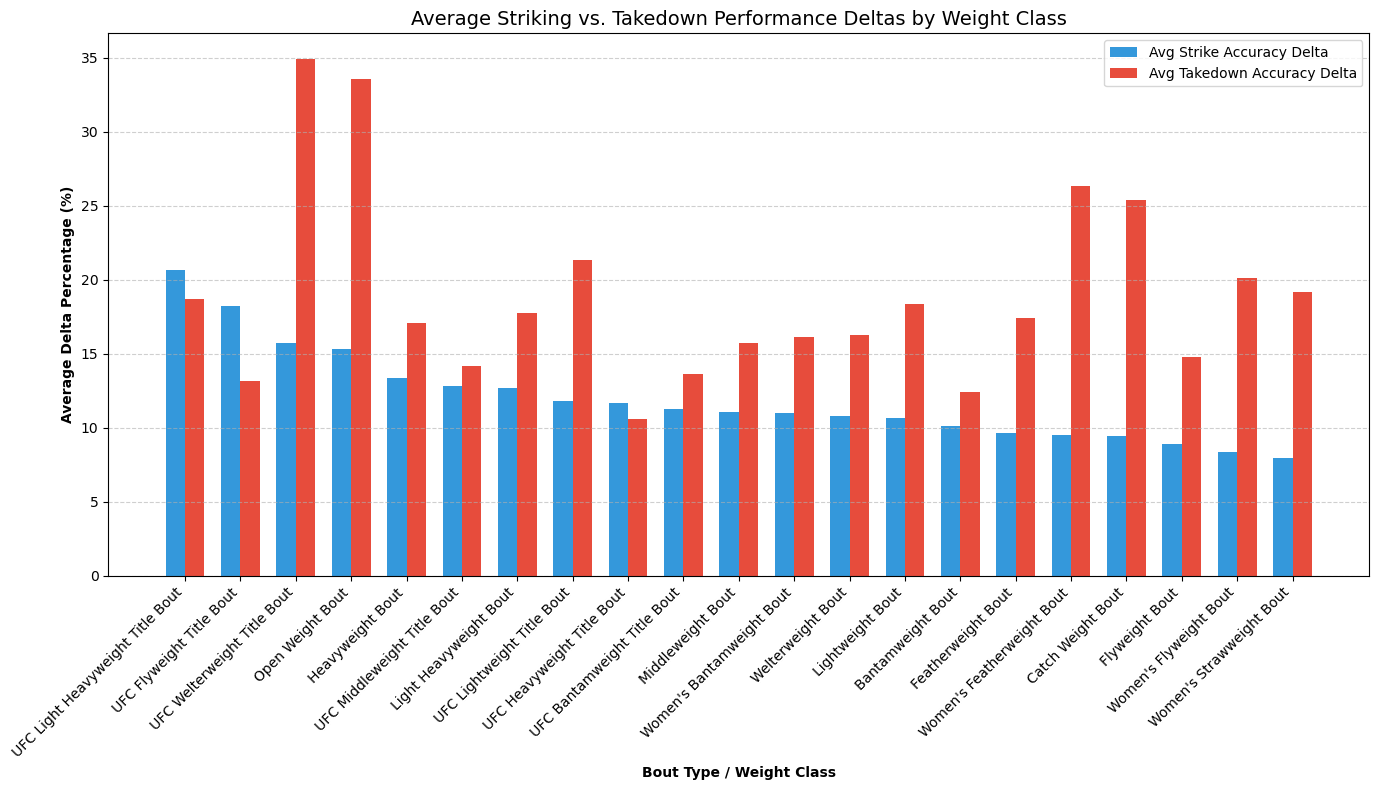

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_processed.csv', sep=';')
df.columns = df.columns.str.strip()

#Group by bout_type and calculate average deltas
#filter for types with at least 20 fights to avoid outliers from rare bout types
bout_counts = df['bout_type'].value_counts()
common_bouts = bout_counts[bout_counts > 20].index
avg_stats = df[df['bout_type'].isin(common_bouts)].groupby('bout_type')[['delta_sig_str_pct', 'delta_TD_pct']].mean()

#Sort by striking delta for better visualization flow
avg_stats = avg_stats.sort_values(by='delta_sig_str_pct', ascending=False)

#Create the Bar Graph
plt.figure(figsize=(14, 8))
x = np.arange(len(avg_stats.index))
width = 0.35

plt.bar(x - width/2, avg_stats['delta_sig_str_pct'], width, label='Avg Strike Accuracy Delta', color='#3498db')
plt.bar(x + width/2, avg_stats['delta_TD_pct'], width, label='Avg Takedown Accuracy Delta', color='#e74c3c')

#Formatting the plot
plt.xlabel('Bout Type / Weight Class', fontweight='bold')
plt.ylabel('Average Delta Percentage (%)', fontweight='bold')
plt.title('Average Striking vs. Takedown Performance Deltas by Weight Class', fontsize=14)
plt.xticks(x, avg_stats.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#